In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ===== FULL ABSOLUTE PATHS (RAW STRINGS) =====

IMAGE_DIR = r"D:\FY_Project\Ai-CDD\data\raw\segmentation_sample\images"

MASK_SAVE_DIR = r"D:\FY_Project\Ai-CDD\data\processed\lung_mask"
LUNG_SAVE_DIR = r"D:\FY_Project\Ai-CDD\data\processed\lung_only"

MODEL_PATH = r"D:\FY_Project\Ai-CDD\models_saved\unet_baseline.keras"

# Create output folders if missing (OpenCV WILL NOT do this)
os.makedirs(MASK_SAVE_DIR, exist_ok=True)
os.makedirs(LUNG_SAVE_DIR, exist_ok=True)


d:\FY_Project\Ai-CDD\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# If custom loss/metric was used
from tensorflow.keras import backend as K

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

loaded_model = load_model(
    MODEL_PATH,
    custom_objects={
        "dice_coef": dice_coef,
        "dice_loss": dice_loss
    },
    safe_mode=False
)

print("✅ Model loaded")



✅ Model loaded


d:\FY_Project\Ai-CDD\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 32 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
IMG_SIZE = 256
THRESH = 0.3

image_files = sorted(os.listdir(IMAGE_DIR))
print("Images found:", len(image_files))

saved_masks = 0

for fname in image_files:
    img_path = os.path.join(IMAGE_DIR, fname)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("❌ Failed to read image:", fname)
        continue

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized / 255.0
    img_input = img_norm[np.newaxis, ..., np.newaxis]  # (1, 256, 256, 1)

    pred = loaded_model.predict(img_input, verbose=0)[0]
    mask = (pred > THRESH).astype(np.uint8) * 255

    save_path = os.path.join(MASK_SAVE_DIR, fname)
    success = cv2.imwrite(save_path, mask)

    if success:
        saved_masks += 1
    else:
        print("❌ Failed to save mask:", fname)

print("✅ Masks saved:", saved_masks)


Images found: 50
✅ Masks saved: 50


In [4]:
saved_lungs = 0

for fname in image_files:
    img_path  = os.path.join(IMAGE_DIR, fname)
    mask_path = os.path.join(MASK_SAVE_DIR, fname)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print("❌ Missing img/mask for:", fname)
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    lung_only = cv2.bitwise_and(img, img, mask=mask)

    save_path = os.path.join(LUNG_SAVE_DIR, fname)
    success = cv2.imwrite(save_path, lung_only)

    if success:
        saved_lungs += 1
    else:
        print("❌ Failed to save lung-only:", fname)

print("✅ Lung-only images saved:", saved_lungs)


✅ Lung-only images saved: 50


In [5]:
print("Mask files:", len(os.listdir(MASK_SAVE_DIR)))
print("Lung-only files:", len(os.listdir(LUNG_SAVE_DIR)))


Mask files: 50
Lung-only files: 50


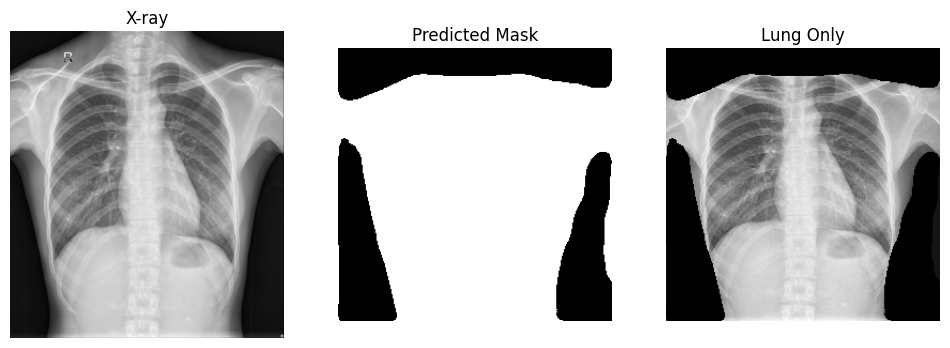

In [6]:
sample = image_files[0]

img  = cv2.imread(os.path.join(IMAGE_DIR, sample), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(os.path.join(MASK_SAVE_DIR, sample), cv2.IMREAD_GRAYSCALE)
lung = cv2.imread(os.path.join(LUNG_SAVE_DIR, sample), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("X-ray")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Lung Only")
plt.imshow(lung, cmap="gray")
plt.axis("off")

plt.show()


In [7]:
import os
import cv2
import numpy as np

LUNG_ONLY_DIR = r"D:\FY_Project\Ai-CDD\data\processed\lung_only"

files = os.listdir(LUNG_ONLY_DIR)

print("Total lung-only images:", len(files))

# Check first 5 images
for f in files[:5]:
    img = cv2.imread(os.path.join(LUNG_ONLY_DIR, f), cv2.IMREAD_GRAYSCALE)
    print(f, "->", img.shape, img.dtype)


Total lung-only images: 50
0001.png -> (256, 256) uint8
0002.png -> (256, 256) uint8
0003.png -> (256, 256) uint8
0004.png -> (256, 256) uint8
0005.png -> (256, 256) uint8


In [8]:
import shutil
import os

SRC_DIR = r"D:\FY_Project\Ai-CDD\data\processed\lung_only"
POOL_DIR = r"D:\FY_Project\Ai-CDD\data\processed\classification_dataset\_unlabeled_pool"

os.makedirs(POOL_DIR, exist_ok=True)

for f in os.listdir(SRC_DIR):
    shutil.copy(
        os.path.join(SRC_DIR, f),
        os.path.join(POOL_DIR, f)
    )

print("Unlabeled pool images:", len(os.listdir(POOL_DIR)))


Unlabeled pool images: 50


In [9]:
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

files = sorted(os.listdir(LUNG_ONLY_DIR))[:3]

for f in files:
    print(f, file_hash(os.path.join(LUNG_ONLY_DIR, f)))


0001.png 1317c0db4177f7573ebafb8b4665af5d
0002.png 572c6e6b1f0cdbfc22387906fd2e1e7e
0003.png aecc677dfaadee79b77ea43f35917147
